# Ridge e Lasso na prática

**Tema:** Aprendizado Supervisionado › Regularização

Este notebook implementa Ridge do zero (via a fórmula fechada do
`teoria.pdf`), confirma contra `sklearn`, e mede diretamente o que a
regularização promete: menos variância entre reamostragens, ao custo de um
pouco de viés — e como Lasso zera coeficientes de features irrelevantes
sozinho.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(3)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. Ridge do zero: a fórmula fechada

In [2]:
def ridge_do_zero(X, y, lam):
    p = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ y)


n, p = 200, 5
X = StandardScaler().fit_transform(rng.normal(0, 1, (n, p)))
beta_real = np.array([3.0, -2.0, 0.0, 0.0, 1.5])
y = X @ beta_real + rng.normal(0, 1, n)

for lam in [0.0, 1.0, 10.0, 100.0]:
    beta_manual = ridge_do_zero(X, y, lam)
    beta_sklearn = Ridge(alpha=lam, fit_intercept=False).fit(X, y).coef_
    diff = np.abs(beta_manual - beta_sklearn).max()
    print(f"lambda={lam:>7.1f}   diferença máxima (manual vs sklearn): {diff:.2e}")

lambda=    0.0   diferença máxima (manual vs sklearn): 4.44e-16
lambda=    1.0   diferença máxima (manual vs sklearn): 4.44e-16
lambda=   10.0   diferença máxima (manual vs sklearn): 4.44e-16
lambda=  100.0   diferença máxima (manual vs sklearn): 4.44e-16


## 2. O efeito de lambda: coeficientes encolhendo, nunca zerando

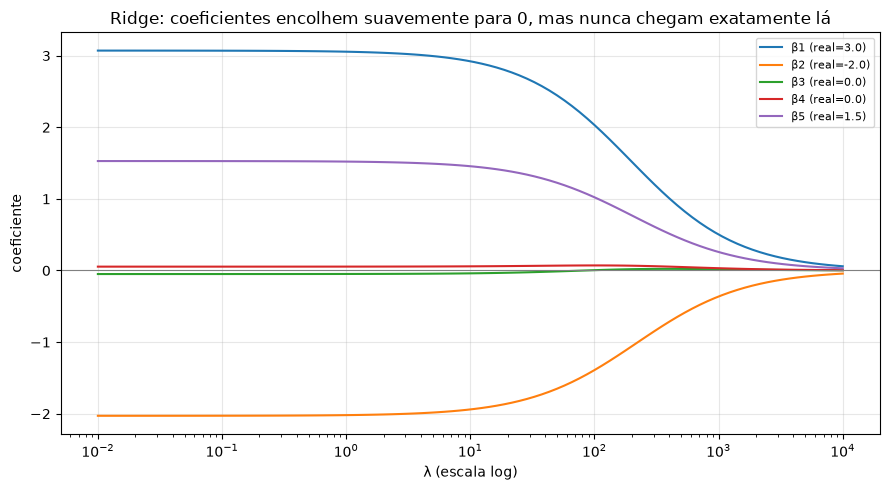

In [3]:
lambdas = np.logspace(-2, 4, 100)
caminho_ridge = np.array([ridge_do_zero(X, y, lam) for lam in lambdas])

fig, ax = plt.subplots(figsize=(9, 5))
for j in range(p):
    ax.plot(lambdas, caminho_ridge[:, j], label=f"β{j+1} (real={beta_real[j]})")
ax.set_xscale("log")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("λ (escala log)"); ax.set_ylabel("coeficiente")
ax.set_title("Ridge: coeficientes encolhem suavemente para 0, mas nunca chegam exatamente lá")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. Lasso: o mesmo experimento, com um resultado bem diferente

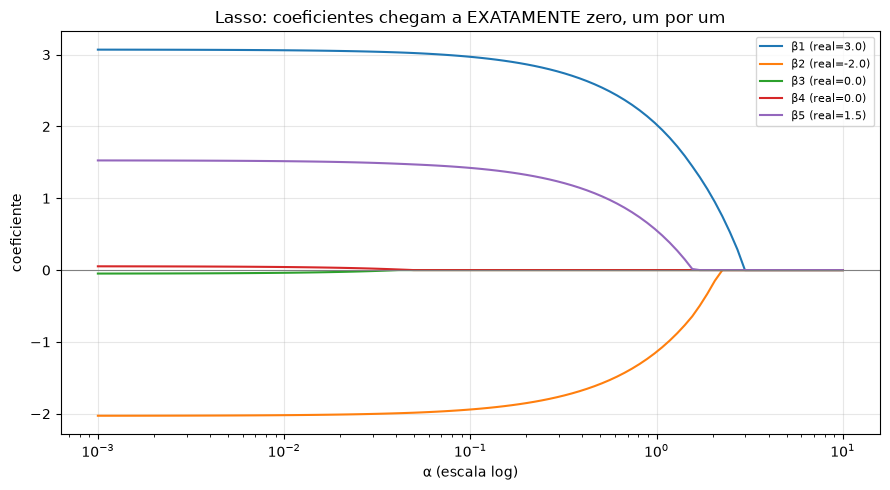

Note que β3 e β4 (que são ZERO de verdade no modelo gerador) são os
primeiros a zerar no caminho do Lasso, conforme alpha cresce — o Lasso
está corretamente identificando as features irrelevantes.


In [4]:
from sklearn.linear_model import lasso_path

alphas_lasso, coefs_lasso, _ = lasso_path(X, y, alphas=np.logspace(-3, 1, 100))

fig, ax = plt.subplots(figsize=(9, 5))
for j in range(p):
    ax.plot(alphas_lasso, coefs_lasso[j], label=f"β{j+1} (real={beta_real[j]})")
ax.set_xscale("log")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("α (escala log)"); ax.set_ylabel("coeficiente")
ax.set_title("Lasso: coeficientes chegam a EXATAMENTE zero, um por um")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print("Note que β3 e β4 (que são ZERO de verdade no modelo gerador) são os")
print("primeiros a zerar no caminho do Lasso, conforme alpha cresce — o Lasso")
print("está corretamente identificando as features irrelevantes.")

## 4. Medindo o trade-off viés-variância diretamente

Repetimos o experimento 300 vezes, cada vez com uma amostra nova, e medimos
a variância dos coeficientes estimados em função de lambda — a promessa
central da regularização, verificada empiricamente.

In [5]:
def experimento_vies_variancia(lam, n_repeticoes=300, n=200, p=5):
    estimativas = []
    for _ in range(n_repeticoes):
        X_rep = StandardScaler().fit_transform(rng.normal(0, 1, (n, p)))
        y_rep = X_rep @ beta_real + rng.normal(0, 1, n)
        if lam == 0:
            beta_est = np.linalg.lstsq(X_rep, y_rep, rcond=None)[0]
        else:
            beta_est = ridge_do_zero(X_rep, y_rep, lam)
        estimativas.append(beta_est)
    estimativas = np.array(estimativas)
    vies = estimativas.mean(axis=0) - beta_real
    variancia = estimativas.var(axis=0)
    return vies, variancia


lambdas_teste = [0.0, 1.0, 5.0, 20.0, 80.0]
print(f"{'lambda':>8s} {'|viés| médio':>14s} {'variância média':>18s} "
      f"{'erro quadrático total':>24s}")
print("-" * 68)
for lam in lambdas_teste:
    vies, var = experimento_vies_variancia(lam)
    erro_total = np.mean(vies**2) + np.mean(var)
    print(f"{lam:>8.1f} {np.mean(np.abs(vies)):>14.4f} {np.mean(var):>18.4f} "
          f"{erro_total:>24.4f}")

  lambda   |viés| médio    variância média    erro quadrático total
--------------------------------------------------------------------


     0.0         0.0023             0.0053                   0.0053


     1.0         0.0085             0.0049                   0.0050


     5.0         0.0358             0.0047                   0.0067


    20.0         0.1231             0.0047                   0.0313


    80.0         0.3738             0.0051                   0.2555


**Leitura esperada:** conforme lambda cresce, o viés aumenta (os
coeficientes encolhem em direção a zero, afastando-se do valor real) mas a
variância cai muito mais rápido no início — o erro quadrático total
(viés² + variância) tende a ter um **mínimo em algum lambda intermediário**,
não em lambda=0. Esse mínimo é exatamente o que a validação cruzada (próximo
notebook) tenta encontrar automaticamente.

## O que levar deste notebook

- A fórmula fechada de Ridge, $(X^\top X + \lambda I)^{-1}X^\top y$, bate
  com `sklearn` e deixa explícito por que Ridge sempre tem solução, mesmo
  com colinearidade perfeita.
- Ridge encolhe coeficientes suavemente; Lasso os zera exatamente, um a um,
  conforme a penalidade cresce — a diferença geométrica do `teoria.pdf` em
  ação.
- O trade-off viés-variância não é uma abstração: dá para medir viés e
  variância diretamente por simulação, e o erro total mínimo raramente
  acontece em lambda=0.

→ Próximo: **A geometria da regularização**, visualizando o losango e o
círculo que explicam por que Lasso zera e Ridge não.